# Aula 1 — Ambiente e primeiros passos

**Objetivo:** preparar o ambiente de desenvolvimento local para o projeto de replicação do artigo.

## O que foi feito
- Criado um ambiente virtual Python (`venv`) — um espaço isolado para instalar as bibliotecas deste projeto sem interferir no restante do sistema.
- Instalado o **Jupyter Notebook**, ferramenta usada para escrever e executar código em células, permitindo testar partes do código separadamente.
- Repositório do projeto clonado do GitHub, já com `.gitignore` configurado para não versionar a pasta `venv/` (ela é grande e pode ser recriada a qualquer momento a partir da lista de dependências).

## Conceitos-chave
- **Ambiente virtual**: espaço isolado de instalação de bibliotecas, evita conflitos entre projetos diferentes.
- **pip**: instalador de pacotes Python, baixa bibliotecas do repositório público PyPI.
- **Jupyter Notebook**: ambiente de código dividido em células executáveis individualmente, cada uma mantendo o estado (variáveis, imports) na memória via um processo chamado *Kernel*.

# Aula 2 — Imagens como números

**Objetivo:** entender como uma imagem é representada internamente como uma grade de números, e aplicar os dois pré-processamentos usados no artigo: *resize* e normalização.

## Conceitos-chave
- Uma imagem é armazenada como um **array** (grade de números): cada número representa a intensidade de um pixel (0 = preto, 255 = branco, em escala de cinza).
- O **shape** de um array descreve suas dimensões. No artigo, cada imagem final tem shape `(300, 300, 3)`: altura, largura e 3 canais de cor.
- **Resize**: redimensiona todas as imagens para o mesmo tamanho (300×300), necessário porque a rede neural espera sempre a mesma quantidade de números de entrada.
- **Normalização**: divide cada pixel por 255, trazendo os valores da faixa 0–255 para 0.0–1.0. Isso deixa o treinamento da rede mais estável.

## Bibliotecas usadas
- **numpy** (`np`): manipulação eficiente de arrays de números.
- **Pillow** (`PIL.Image`): abrir e descomprimir arquivos de imagem (PNG/JPEG), e aplicar o resize.
- **matplotlib** (`plt`): visualizar imagens e gráficos.
- **os**: montar caminhos de arquivo de forma segura entre diferentes sistemas operacionais (`os.path.join`).

## Observação importante
Todo o processamento (abrir, redimensionar, normalizar) acontece **na memória RAM**, de forma temporária — os arquivos originais no disco nunca são alterados. Isso é intencional: preserva os dados brutos como referência, e permite reprocessar a qualquer momento sem risco de perda.

In [1]:
import numpy as np

# Criando uma "imagem" bem pequena e falsa, só pra entender o conceito
# Imagine uma imagem de 4x4 pixels, em escala de cinza (1 canal só, por enquanto)
imagem_exemplo = np.array([
    [0,   50,  100, 150],
    [200, 255, 255, 200],
    [150, 100, 50,  0],
    [0,   0,   0,   0]
])

print("Formato (shape) da imagem:", imagem_exemplo.shape)
print(imagem_exemplo)

Formato (shape) da imagem: (4, 4)
[[  0  50 100 150]
 [200 255 255 200]
 [150 100  50   0]
 [  0   0   0   0]]


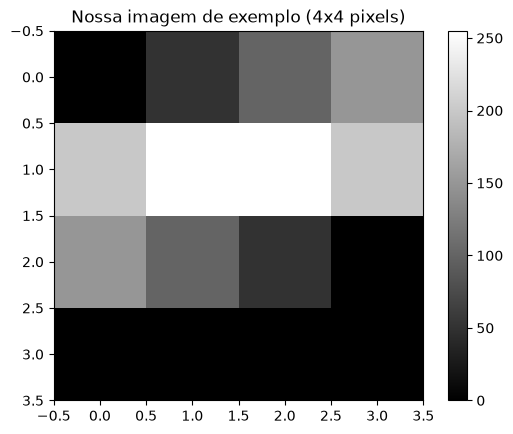

In [2]:
import matplotlib.pyplot as plt

plt.imshow(imagem_exemplo, cmap='gray')
plt.colorbar()  # mostra a escala de cores ao lado, pra você conferir os valores
plt.title("Nossa imagem de exemplo (4x4 pixels)")
plt.show()

Caminho montado: /home/gustavo/Documentos/Base de dados de raio x de torax/Covid-19/COVID-19_Radiography_Dataset/COVID/images/COVID-1.png
Formato (shape) da imagem real: (299, 299)


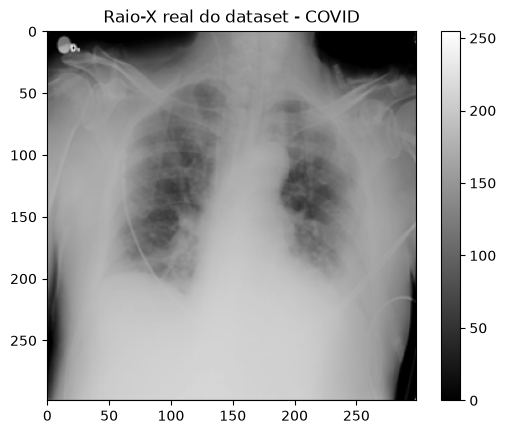

In [3]:
import os
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from config import RAIZ_COVID, RAIZ_PNEUMONIA, RAIZ_TUBERCULOSE

# ===== Definindo as raízes de cada dataset =====


# ===== Montando o caminho completo até uma imagem específica de teste =====
caminho_imagem_covid = os.path.join(RAIZ_COVID, "COVID", "images", "COVID-1.png")

print("Caminho montado:", caminho_imagem_covid)

# ===== Carregando e exibindo essa imagem =====
imagem = Image.open(caminho_imagem_covid)
imagem_array = np.array(imagem)

print("Formato (shape) da imagem real:", imagem_array.shape)

plt.imshow(imagem_array, cmap='gray')
plt.colorbar()
plt.title("Raio-X real do dataset - COVID")
plt.show()

# Aula 3 — Organizando o dataset

**Objetivo:** unificar as 3 bases de dados originais (com estruturas internas diferentes) em uma única estrutura de 4 classes, no formato que o Keras espera.

## O que foi feito
- Exploração da estrutura real de cada dataset com uma função recursiva de listagem de pastas.
- Identificação de arquivos irrelevantes (metadados, arquivos de sistema do macOS) que não fazem parte das imagens.
- Descoberta de uma divergência entre o artigo e o dataset real de Tuberculose: a Tabela 2 do artigo afirma 3500 imagens de Tuberculosis, mas o dataset real (IEEE DataPort) tem apenas 700 imagens de Tuberculosis (as 3500 pertencem, na verdade, à classe Normal desse dataset). **Decisão tomada:** usar os 700 dados reais de Tuberculosis, por entender que o artigo provavelmente cometeu um erro de documentação, não de execução do experimento.
- Confirmação de que o dataset de Pneumonia usa extensão `.jpeg` (não `.png`) e está subdividido em `train/test/val`, sendo necessário somar as 3 divisões para bater com os 4273 exemplares do artigo.
- Criação da pasta `dataset_unificado/`, com 4 subpastas (`COVID-19/`, `Normal/`, `Pneumonia/`, `Tuberculosis/`), cada uma contendo **links simbólicos** para as imagens originais.

## Conceitos-chave
- **Link simbólico (symlink)**: um "atalho" no sistema de arquivos que aponta para um arquivo real, sem duplicar dados em disco. Criado com `os.symlink()`.
- **Função e recursão**: uma função que chama a si mesma, usada para navegar por estruturas de pasta de profundidade desconhecida.
- **List comprehension**: forma compacta de filtrar/transformar listas em uma linha (`[x for x in lista if condição]`).
- **set (conjunto)**: estrutura de dados sem repetição, usada para comparar dois grupos de arquivos e verificar se são idênticos.

## Contagem final por classe
| Classe | Quantidade | Fonte |
|---|---|---|
| COVID-19 | 3616 | dataset COVID |
| Normal | 10192 | dataset COVID |
| Pneumonia | 4273 | dataset Pneumonia (train+test+val) |
| Tuberculosis | 700 | dataset Tuberculose (divergência com o artigo documentada) |

## Observação importante
A pasta `dataset_unificado/` não é versionada no Git — ela é derivada dos datasets originais e do código desta aula, e pode ser recriada a qualquer momento rodando as células desta seção.

In [4]:
import os

def explorar_pasta(caminho, nivel=0, max_nivel=2):
    """
    Mostra a estrutura de pastas de forma organizada, como uma árvore.
    'nivel' controla a indentação (profundidade atual).
    'max_nivel' limita até onde descer, pra não imprimir milhares de arquivos.
    """
    if nivel > max_nivel:
        return
    
    try:
        itens = os.listdir(caminho)
    except NotADirectoryError:
        return
    
    for item in sorted(itens):
        caminho_completo = os.path.join(caminho, item)
        prefixo = "  " * nivel + "- "
        print(prefixo + item)
        if os.path.isdir(caminho_completo):
            explorar_pasta(caminho_completo, nivel + 1, max_nivel)

print("=== Estrutura do dataset COVID ===")
explorar_pasta(RAIZ_COVID)

=== Estrutura do dataset COVID ===
- COVID
  - images
    - COVID-1.png
    - COVID-10.png
    - COVID-100.png
    - COVID-1000.png
    - COVID-1001.png
    - COVID-1002.png
    - COVID-1003.png
    - COVID-1004.png
    - COVID-1005.png
    - COVID-1006.png
    - COVID-1007.png
    - COVID-1008.png
    - COVID-1009.png
    - COVID-101.png
    - COVID-1010.png
    - COVID-1011.png
    - COVID-1012.png
    - COVID-1013.png
    - COVID-1014.png
    - COVID-1015.png
    - COVID-1016.png
    - COVID-1017.png
    - COVID-1018.png
    - COVID-1019.png
    - COVID-102.png
    - COVID-1020.png
    - COVID-1021.png
    - COVID-1022.png
    - COVID-1023.png
    - COVID-1024.png
    - COVID-1025.png
    - COVID-1026.png
    - COVID-1027.png
    - COVID-1028.png
    - COVID-1029.png
    - COVID-103.png
    - COVID-1030.png
    - COVID-1031.png
    - COVID-1032.png
    - COVID-1033.png
    - COVID-1034.png
    - COVID-1035.png
    - COVID-1036.png
    - COVID-1037.png
    - COVID-1038.png
    - COVI

In [19]:
print("=== Estrutura do dataset COVID ===")
explorar_pasta(RAIZ_COVID, max_nivel=1)

print("\n=== Estrutura do dataset Pneumonia ===")
explorar_pasta(RAIZ_PNEUMONIA, max_nivel=1)

print("\n=== Estrutura do dataset Tuberculose ===")
explorar_pasta(RAIZ_TUBERCULOSE, max_nivel=1)

=== Estrutura do dataset COVID ===
- COVID
  - images
  - masks
- COVID.metadata.xlsx
- Lung_Opacity
  - images
  - masks
- Lung_Opacity.metadata.xlsx
- Normal
  - images
  - masks
- Normal.metadata.xlsx
- README.md.txt
- Viral Pneumonia
  - images
  - masks
- Viral Pneumonia.metadata.xlsx

=== Estrutura do dataset Pneumonia ===
- __MACOSX
  - ._chest_xray
  - chest_xray
- chest_xray
  - .DS_Store
  - test
  - train
  - val
- test
  - NORMAL
  - PNEUMONIA
- train
  - NORMAL
  - PNEUMONIA
- val
  - NORMAL
  - PNEUMONIA

=== Estrutura do dataset Tuberculose ===
- Normal
  - Normal-1.png
  - Normal-10.png
  - Normal-100.png
  - Normal-1000.png
  - Normal-1001.png
  - Normal-1002.png
  - Normal-1003.png
  - Normal-1004.png
  - Normal-1005.png
  - Normal-1006.png
  - Normal-1007.png
  - Normal-1008.png
  - Normal-1009.png
  - Normal-101.png
  - Normal-1010.png
  - Normal-1011.png
  - Normal-1012.png
  - Normal-1013.png
  - Normal-1014.png
  - Normal-1015.png
  - Normal-1016.png
  - Normal-1

In [18]:
import os

PASTA_UNIFICADA = "dataset_unificado"

def criar_link_simbolico(origem, destino):
    """Cria um link simbólico de 'origem' apontando para 'destino', 
    ignorando se o link já existir (evita erro ao rodar o código de novo)."""
    if not os.path.exists(destino):
        os.symlink(origem, destino)

def organizar_classe(nome_classe, lista_pastas_origem, extensao):
    """
    Cria a pasta da classe dentro do dataset unificado, e para cada
    pasta de origem informada, cria links simbólicos para cada imagem 
    encontrada nela.
    """
    pasta_destino = os.path.join(PASTA_UNIFICADA, nome_classe)
    os.makedirs(pasta_destino, exist_ok=True)
    
    contador = 0
    for pasta_origem in lista_pastas_origem:
        if not os.path.isdir(pasta_origem):
            print(f"AVISO: pasta não encontrada, pulando: {pasta_origem}")
            continue
        
        for nome_arquivo in os.listdir(pasta_origem):
            if nome_arquivo.lower().endswith(extensao):
                caminho_origem_completo = os.path.abspath(os.path.join(pasta_origem, nome_arquivo))
                caminho_destino_completo = os.path.join(pasta_destino, nome_arquivo)
                criar_link_simbolico(caminho_origem_completo, caminho_destino_completo)
                contador += 1
    
    print(f"Classe '{nome_classe}': {contador} imagens linkadas.")

# ===== COVID-19 =====
organizar_classe(
    "COVID-19",
    [os.path.join(RAIZ_COVID, "COVID", "images")],
    ".png"
)

# ===== Normal (só do dataset COVID, replicando o artigo) =====
organizar_classe(
    "Normal",
    [os.path.join(RAIZ_COVID, "Normal", "images")],
    ".png"
)

# ===== Pneumonia (juntando train+test+val) =====
organizar_classe(
    "Pneumonia",
    [
        os.path.join(RAIZ_PNEUMONIA, "chest_xray", "train", "PNEUMONIA"),
        os.path.join(RAIZ_PNEUMONIA, "chest_xray", "test", "PNEUMONIA"),
        os.path.join(RAIZ_PNEUMONIA, "chest_xray", "val", "PNEUMONIA"),
    ],
    ".jpeg"
)

# ===== Tuberculosis (usando os 700 reais, decisão documentada) =====
organizar_classe(
    "Tuberculosis",
    [os.path.join(RAIZ_TUBERCULOSE, "Tuberculosis")],
    ".png"
)

Classe 'COVID-19': 3616 imagens linkadas.
Classe 'Normal': 10192 imagens linkadas.
Classe 'Pneumonia': 4273 imagens linkadas.
Classe 'Tuberculosis': 700 imagens linkadas.
